In [ ]:
import json
import pandas as pd

# Load the datasets
train = pd.read_csv('/content/train.tsv', sep='\t', header=None)
dev = pd.read_csv('/content/dev.tsv', sep='\t', header=None)
test = pd.read_csv('/content/test.tsv', sep='\t', header=None)

# Assign meaningful column names
train.columns = ['text', 'labels', 'id']
dev.columns = ['text', 'labels', 'id']
test.columns = ['text', 'labels', 'id']

# Placeholder for train_data, val_data, test_data (these need to be defined based on the model/data generator used)
# For now, commenting out the lines that cause NameError for train_data, val_data, test_data
# classes = train_data.class_indices
# json.dump(classes, open("class_map.json", "w"))
# print("Train batches:", train_data.samples)
# print("Val batches:", val_data.samples)
# print("Test batches:", test_data.samples)

with open("emotions.txt") as f:
    emotions = [line.strip() for line in f]

def convert_ids(label_string):
    if pd.isna(label_string):
        return []
    return [int(x) for x in str(label_string).split(",")]

train["label_ids"] = train["labels"].apply(convert_ids)
dev["label_ids"]   = dev["labels"].apply(convert_ids)
test["label_ids"]  = test["labels"].apply(convert_ids)

def id_to_emotions(id_list):
    return [emotions[i] for i in id_list]

train["emotion_list"] = train["label_ids"].apply(id_to_emotions)
dev["emotion_list"]   = dev["label_ids"].apply(id_to_emotions)
test["emotion_list"]  = test["label_ids"].apply(id_to_emotions)

mapping = {
    'joy':'happy', 'amusement':'happy','approval':'happy','admiration':'happy','gratitude':'happy','pride':'happy','relief':'happy',

    'love':'love',

    'sadness':'sad','disappointment':'sad','grief':'sad','remorse':'sad',

    'anger':'angry','annoyance':'angry',

    'fear':'fear','nervousness':'fear',

    'disgust':'disgust',

    'neutral':'neutral'
}

def reduce_label(emotion_list):
    for e in emotion_list:
        if e in mapping:
            return mapping[e]
    return None

train["reduced"] = train["emotion_list"].apply(reduce_label)
dev["reduced"]   = dev["emotion_list"].apply(reduce_label)
test["reduced"]  = test["emotion_list"].apply(reduce_label)

train = train.dropna(subset=["reduced"])
dev   = dev.dropna(subset=["reduced"])
test  = test.dropna(subset=["reduced"])

import re

def clean(text):
    text = text.lower()
    text = re.sub(r"http\S+","", text)
    return text

train["clean_text"] = train["text"].apply(clean)
dev["clean_text"]   = dev["text"].apply(clean)
test["clean_text"]  = test["text"].apply(clean)

In [ ]:
label_map = {
    'happy': 0,
    'sad': 1,
    'angry': 2,
    'fear': 3,
    'love': 4,
    'neutral': 5,
    'disgust': 6
}

train["label_id"] = train["reduced"].map(label_map)
dev["label_id"]   = dev["reduced"].map(label_map)
test["label_id"]  = test["reduced"].map(label_map)


In [ ]:
print(train["label_id"].value_counts())


label_id
5    13386
0    12483
2     3685
1     2599
4     1654
3      653
6      625
Name: count, dtype: int64


Data Imbalancing

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

labels = train["label_id"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(0.40151749236103956), 1: np.float64(1.9284889792777442), 2: np.float64(1.360147315371196), 3: np.float64(7.675563334062568), 4: np.float64(3.0303161167731907), 5: np.float64(0.37443170903502593), 6: np.float64(8.019428571428572)}


Training

In [ ]:
!pip install transformers


In [ ]:
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments


In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=7
)

# Explicitly move model to GPU if available
if torch.cuda.is_available():
    model.to('cuda')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
train_encodings = tokenizer(
    train["clean_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    dev["clean_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)


In [ ]:
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [ ]:
train_dataset = EmotionDataset(train_encodings, train["label_id"].values)
val_dataset   = EmotionDataset(val_encodings, dev["label_id"].values)


In [ ]:
weights = torch.tensor(list(class_weights.values()), dtype=torch.float)
# Move weights to the same device as the model
weights = weights.to(model.device)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=30,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True
)

In [ ]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()


Epoch,Training Loss,Validation Loss
1,0.905200,0.908631
2,0.748500,0.927309
3,0.534400,1.050526
4,0.390600,1.304226
5,0.236400,1.639222
6,0.182900,1.992863
7,0.141900,2.207971


Epoch,Training Loss,Validation Loss
1,0.905200,0.908631
2,0.748500,0.927309
3,0.534400,1.050526
4,0.390600,1.304226
5,0.236400,1.639222
6,0.182900,1.992863
7,0.141900,2.207971
8,0.112300,2.658559
9,0.072300,2.868311
10,0.058800,3.025020


TrainOutput(global_step=65790, training_loss=0.12523759822182098, metrics={'train_runtime': 12033.1839, 'train_samples_per_second': 87.471, 'train_steps_per_second': 5.467, 'total_flos': 3.48602482518912e+16, 'train_loss': 0.12523759822182098, 'epoch': 30.0})

In [ ]:
eval_results = trainer.evaluate(val_dataset)
print(eval_results)

{'eval_loss': 0.908631443977356, 'eval_runtime': 7.1291, 'eval_samples_per_second': 613.679, 'eval_steps_per_second': 38.434, 'epoch': 30.0}


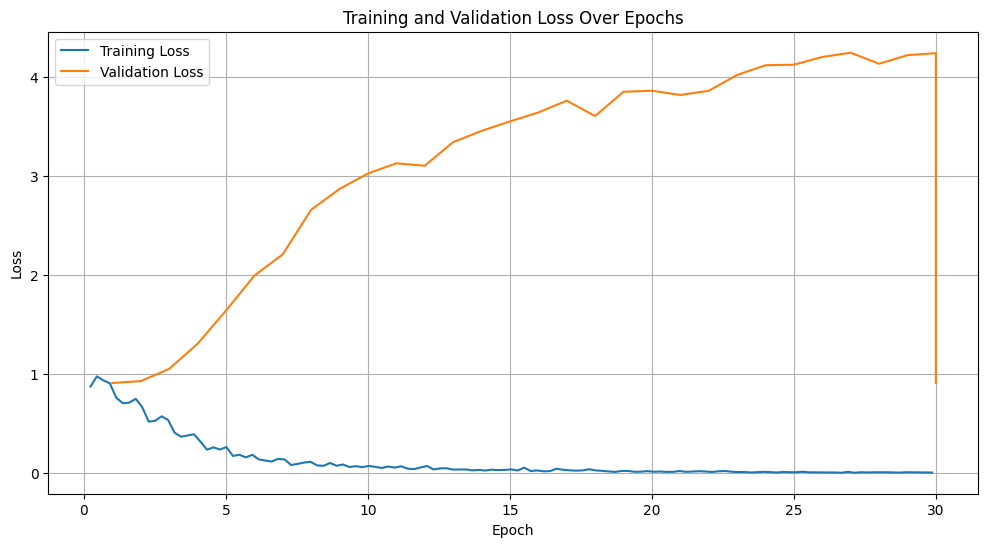

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract logs from trainer state
logs = trainer.state.log_history

# Filter for training and evaluation logs
train_logs = [log for log in logs if 'loss' in log and 'learning_rate' in log]
eval_logs = [log for log in logs if 'eval_loss' in log]

# Prepare data for plotting
train_epochs = [log['epoch'] for log in train_logs]
train_losses = [log['loss'] for log in train_logs]

eval_epochs = [log['epoch'] for log in eval_logs]
eval_losses = [log['eval_loss'] for log in eval_logs]

# Create plots
plt.figure(figsize=(12, 6))

# Plot Loss
plt.plot(train_epochs, train_losses, label='Training Loss')
plt.plot(eval_epochs, eval_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

# Get predictions from the trainer
predictions = trainer.predict(val_dataset)

# The predictions object contains logits, true labels, and metrics
logits = predictions.predictions
true_labels = predictions.label_ids

# Get predicted labels by taking the argmax of the logits
predicted_labels = np.argmax(logits, axis=1)

# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_labels)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.7127


In [ ]:
# Prepare test encodings
test_encodings = tokenizer(
    test["clean_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

# Create test dataset
test_dataset = EmotionDataset(test_encodings, test["label_id"].values)

# Get predictions from the trainer on the test dataset
predictions_test = trainer.predict(test_dataset)

# Extract logits and true labels
logits_test = predictions_test.predictions
true_labels_test = predictions_test.label_ids

# Get predicted labels
predicted_labels_test = np.argmax(logits_test, axis=1)

# Calculate test accuracy
test_accuracy = accuracy_score(true_labels_test, predicted_labels_test)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7220


In [ ]:
model.save_pretrained("text_emotion_model")
tokenizer.save_pretrained("text_emotion_model")


('text_emotion_model/tokenizer_config.json',
 'text_emotion_model/special_tokens_map.json',
 'text_emotion_model/vocab.txt',
 'text_emotion_model/added_tokens.json',
 'text_emotion_model/tokenizer.json')

In [ ]:
!zip -r text_emotion_model.zip text_emotion_model


  adding: text_emotion_model/ (stored 0%)
  adding: text_emotion_model/tokenizer.json (deflated 71%)
  adding: text_emotion_model/model.safetensors (deflated 8%)
  adding: text_emotion_model/config.json (deflated 53%)
  adding: text_emotion_model/vocab.txt (deflated 53%)
  adding: text_emotion_model/special_tokens_map.json (deflated 42%)
  adding: text_emotion_model/tokenizer_config.json (deflated 75%)


In [ ]:
from google.colab import files

files.download("text_emotion_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>